In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import completeness_score, silhouette_score


In [13]:
import os
print(os.getcwd())

/Users/sagihaider/GitHub/ce888/Week03/Lecture


In [3]:
# -----------------------------
# 1) Generate synthetic 2D isotropic Gaussian blobs
# -----------------------------
X_blobs, y_true = make_blobs(
    n_samples=2000,
    n_features=2,
    centers=None,          # unknown / randomly generated centres
    cluster_std=1.5,       # isotropic (same std in all directions)
    center_box=(-10.0, 10.0),
    shuffle=True,
    random_state=10
)

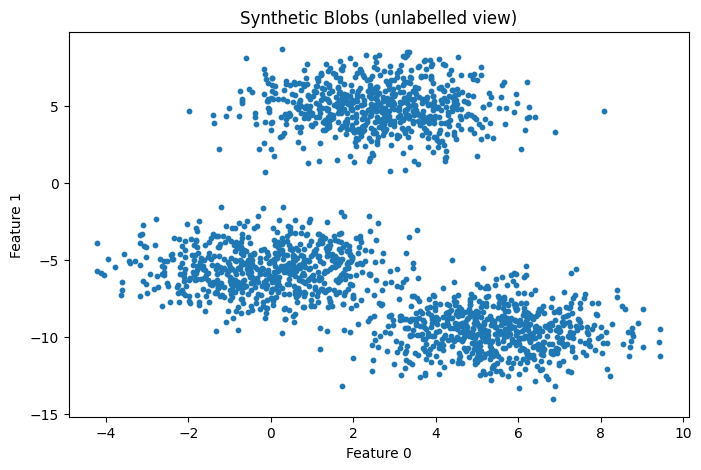

In [17]:
# -----------------------------
# 2) Visualise the raw data
# -----------------------------
import os
plt.figure(figsize=(8, 5))
plt.title("Synthetic Blobs (unlabelled view)")
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], s=10)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.savefig(os.path.abspath("../../Figures/Lec3-blobs_unlabelled.png"))
plt.show()

/Users/sagihaider/GitHub/ce888/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/sagihaider/GitHub/ce888/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/sagihaider/GitHub/ce888/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/sagihaider/GitHub/ce888/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/sagihaider/GitHub/ce888/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/sagihaider/GitHub/ce888/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value enco

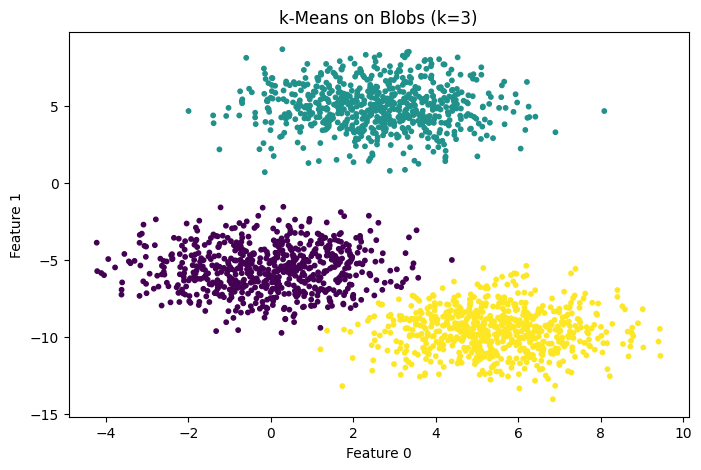

In [18]:
# -----------------------------
# 3) Apply k-means with k = 3
# -----------------------------
kmeans = KMeans(n_clusters=3, n_init=10, random_state=10)
y_pred = kmeans.fit_predict(X_blobs)

# Visualise clustered result
plt.figure(figsize=(8, 5))
plt.title("k-Means on Blobs (k=3)")
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_pred, s=10)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.savefig(os.path.abspath("../../Figures/Lec3-blobs_clustered.png"))
plt.show()


In [5]:
# -----------------------------
# 4) Compute completeness + silhouette
# -----------------------------
comp = completeness_score(y_true, y_pred)      # needs ground truth labels
sil  = silhouette_score(X_blobs, y_pred)       # label-free internal metric

print(f"Completeness score = {comp:.3f}")
print(f"Silhouette score   = {sil:.3f}")


Completeness score = 0.967
Silhouette score   = 0.664


/Users/sagihaider/GitHub/ce888/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/sagihaider/GitHub/ce888/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/sagihaider/GitHub/ce888/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


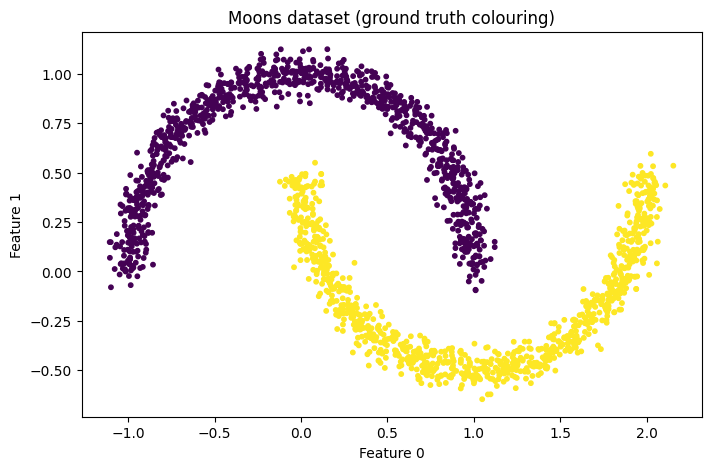

/Users/sagihaider/GitHub/ce888/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/sagihaider/GitHub/ce888/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/sagihaider/GitHub/ce888/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/sagihaider/GitHub/ce888/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/sagihaider/GitHub/ce888/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/sagihaider/GitHub/ce888/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value enco

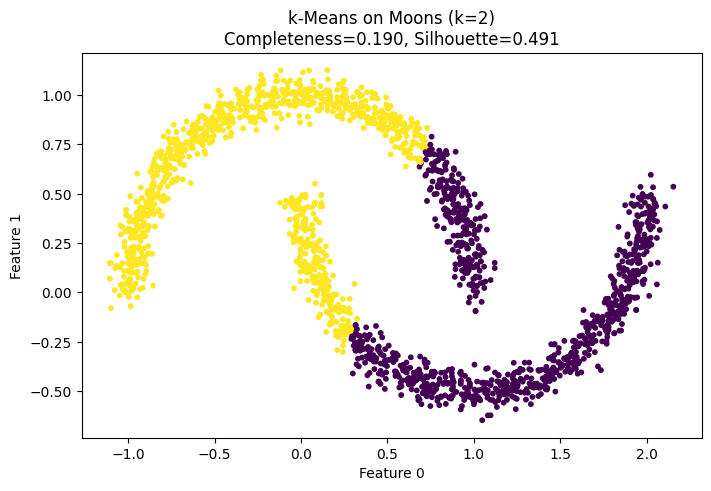

k=2: Completeness=0.190, Silhouette=0.491


/Users/sagihaider/GitHub/ce888/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/sagihaider/GitHub/ce888/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/sagihaider/GitHub/ce888/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/sagihaider/GitHub/ce888/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/sagihaider/GitHub/ce888/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/sagihaider/GitHub/ce888/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value enco

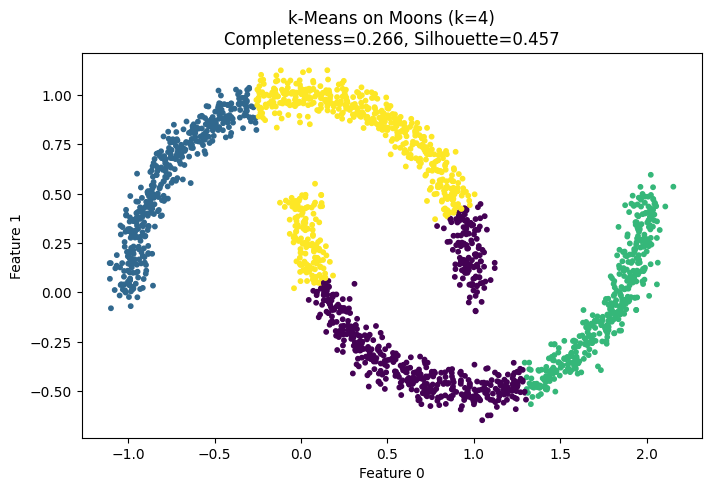

k=4: Completeness=0.266, Silhouette=0.457


In [19]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.cluster import KMeans
from sklearn.metrics import completeness_score, silhouette_score

# -----------------------------
# 1) Generate Moons dataset (true structure: k=2, non-spherical)
# -----------------------------
X, y_true = make_moons(n_samples=2000, noise=0.05, random_state=10)

plt.figure(figsize=(8, 5))
plt.title("Moons dataset (ground truth colouring)")
plt.scatter(X[:, 0], X[:, 1], c=y_true, s=10)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()

def run_kmeans_and_plot(k: int):
    km = KMeans(n_clusters=k, n_init=10, random_state=10)
    y_pred = km.fit_predict(X)

    comp = completeness_score(y_true, y_pred)     # external (needs y_true)
    sil  = silhouette_score(X, y_pred)            # internal

    plt.figure(figsize=(8, 5))
    plt.title(f"k-Means on Moons (k={k})\nCompleteness={comp:.3f}, Silhouette={sil:.3f}")
    plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=10)
    plt.xlabel("Feature 0")
    plt.ylabel("Feature 1")
    plt.show()

    print(f"k={k}: Completeness={comp:.3f}, Silhouette={sil:.3f}")

# -----------------------------
# 2) k-means with k=2 (poor fit: spherical assumption)
# -----------------------------
run_kmeans_and_plot(k=2)

# -----------------------------
# 3) k-means with k=4 (slightly higher completeness, but splits a moon)
# -----------------------------
run_kmeans_and_plot(k=4)


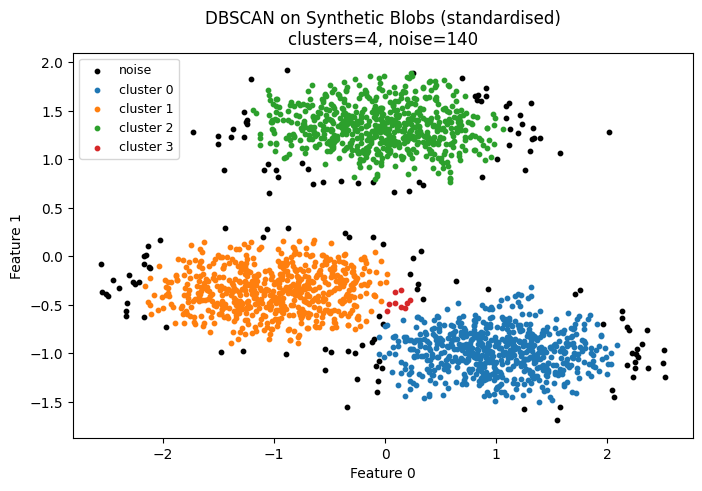

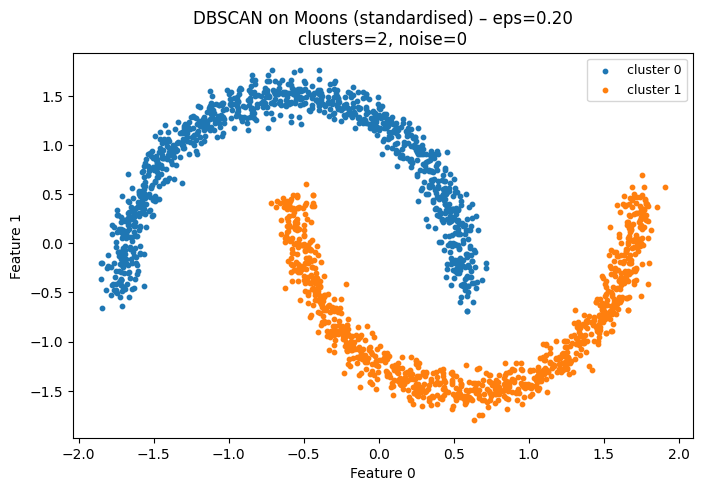

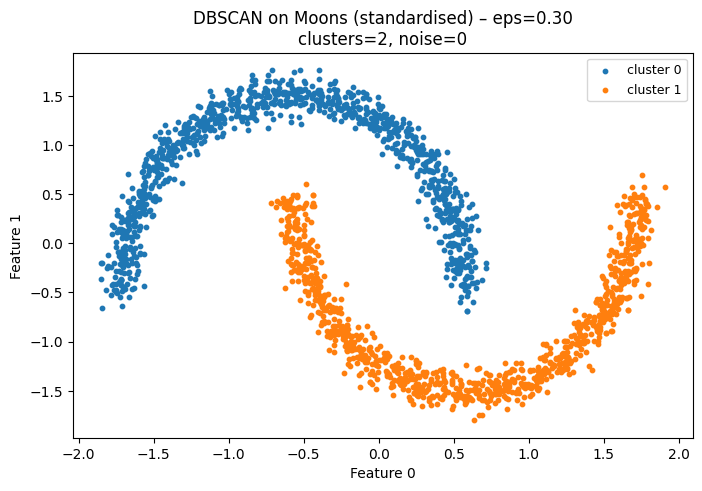

Blobs: clusters=4, noise=140, labels=[np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Moons eps=0.20: clusters=2, noise=0, labels=[np.int64(0), np.int64(1)]
Moons eps=0.30: clusters=2, noise=0, labels=[np.int64(0), np.int64(1)]


In [20]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# -----------------------------
# Helper: plot DBSCAN result
# -----------------------------
def plot_dbscan(X, labels, title):
    # labels: -1 = noise (outliers), 0..K-1 = cluster ids
    n_noise = int(np.sum(labels == -1))
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    plt.figure(figsize=(8, 5))
    plt.title(f"{title}\nclusters={n_clusters}, noise={n_noise}")

    # Plot clusters and noise (noise shown in black)
    unique_labels = sorted(set(labels))
    for lab in unique_labels:
        mask = labels == lab
        if lab == -1:
            plt.scatter(X[mask, 0], X[mask, 1], s=10, c="black", label="noise")
        else:
            plt.scatter(X[mask, 0], X[mask, 1], s=10, label=f"cluster {lab}")

    plt.xlabel("Feature 0")
    plt.ylabel("Feature 1")
    plt.legend(loc="best", fontsize=9)
    plt.show()


# =========================================================
# 1) DBSCAN on Synthetic Blobs (no need to specify k)
# =========================================================
X_blobs, _ = make_blobs(
    n_samples=2000,
    n_features=2,
    centers=None,
    cluster_std=1.5,
    center_box=(-10.0, 10.0),
    shuffle=True,
    random_state=10
)

# DBSCAN is distance-based under the hood -> scaling matters
Xb = StandardScaler().fit_transform(X_blobs)

# Tune eps/min_samples to your data scale/density
db_blobs = DBSCAN(eps=0.15, min_samples=10)
labels_blobs = db_blobs.fit_predict(Xb)

plot_dbscan(Xb, labels_blobs, "DBSCAN on Synthetic Blobs (standardised)")


# =========================================================
# 2) DBSCAN on Moons (captures non-spherical structure)
# =========================================================
X_moons, y_true = make_moons(n_samples=2000, noise=0.05, random_state=10)

# You can scale here too; for moons, raw scale is already reasonable,
# but scaling is still a good default habit.
Xm = StandardScaler().fit_transform(X_moons)

# Two parameter settings (show how eps changes the story)
db_moons_1 = DBSCAN(eps=0.20, min_samples=5)
labels_moons_1 = db_moons_1.fit_predict(Xm)
plot_dbscan(Xm, labels_moons_1, "DBSCAN on Moons (standardised) – eps=0.20")

db_moons_2 = DBSCAN(eps=0.30, min_samples=5)
labels_moons_2 = db_moons_2.fit_predict(Xm)
plot_dbscan(Xm, labels_moons_2, "DBSCAN on Moons (standardised) – eps=0.30")


# -----------------------------
# Quick interpretation hooks (printed)
# -----------------------------
def summarize(labels, name):
    n_noise = int(np.sum(labels == -1))
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"{name}: clusters={n_clusters}, noise={n_noise}, labels={sorted(set(labels))[:10]}{'...' if len(set(labels))>10 else ''}")

summarize(labels_blobs,  "Blobs")
summarize(labels_moons_1, "Moons eps=0.20")
summarize(labels_moons_2, "Moons eps=0.30")


In [21]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load data
X = load_iris().data

# Standardise features
X_std = StandardScaler().fit_transform(X)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

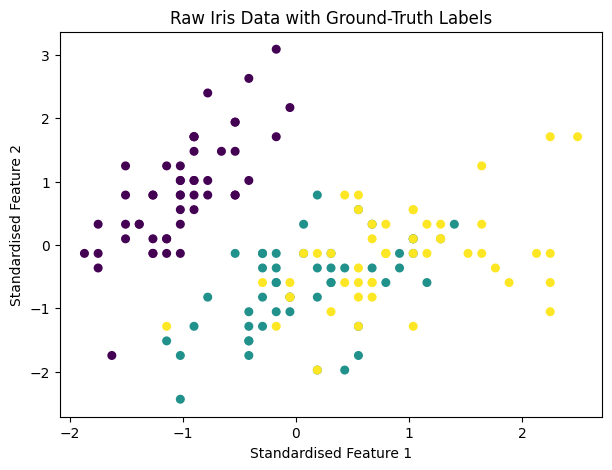

In [23]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load Iris data
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# Standardise features
X_std = StandardScaler().fit_transform(X)

# Plot raw data (first two features) with true labels
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    X_std[:, 0],
    X_std[:, 1],
    c=y,
    s=30
)

plt.xlabel("Standardised Feature 1")
plt.ylabel("Standardised Feature 2")
plt.title("Raw Iris Data with Ground-Truth Labels")

# Legend
plt.legend(
    handles=scatter.legend_elements()[0],
    labels=target_names,
    title="Class",
    loc="best"
)

plt.show()

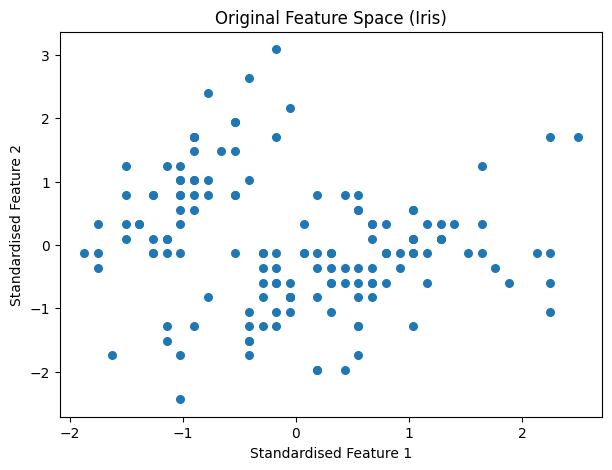

In [24]:
plt.figure(figsize=(7, 5))
plt.scatter(X_std[:, 0], X_std[:, 1], s=30)
plt.xlabel("Standardised Feature 1")
plt.ylabel("Standardised Feature 2")
plt.title("Original Feature Space (Iris)")
plt.show()

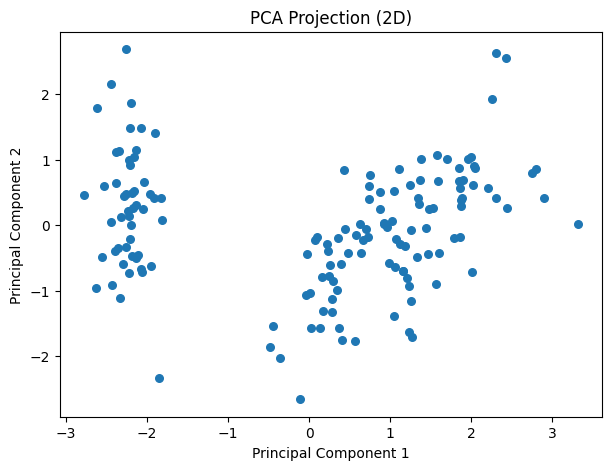

In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=30)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection (2D)")
plt.show()

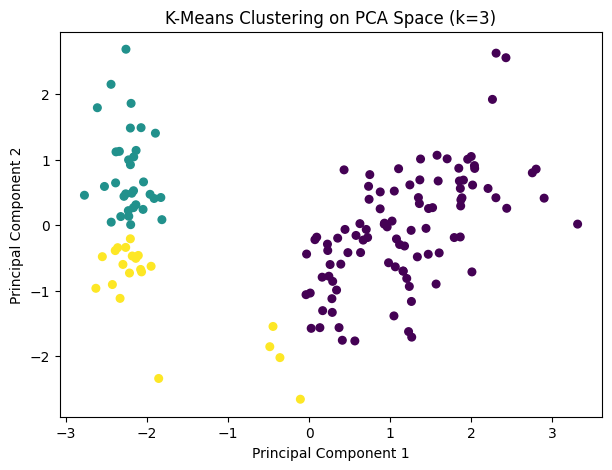

In [26]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, s=30)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering on PCA Space (k=3)")
plt.show()